$$
u'=\sin[(u+t)^2], \quad t \in [0,4], \quad u(0)=-1
$$

1. Function that computes $u'$
2. Initial value for $u$
3. Endpoints of the interval for $t$

In [ ]:
f(u, p, t) = sin((t + u)^2)     # defines du/dt, must include p argument
u₀ = -1.0                       # initial value
tspan = (0.0, 4.0)              # t interval

In [ ]:
using OrdinaryDiffEq
ivp = ODEProblem(f, u₀, tspan)
sol = solve(ivp);

In [ ]:
using Plots, LaTeXStrings
theme(:dark);  default(thickness_scaling=1.4)
plot(sol; label="solution", legend=:bottom, xlabel="t",  ylabel=L"u(t)")

In [ ]:
sol.t

In [ ]:
sol.u

In [ ]:
scatter!(sol.t, sol.u, label="discrete values")

In [ ]:
sol(1.0)

## Example 6.1.3

$$u'=(u+t)^2, \: u(0) = 1, \: t \in (0, 1)$$ 

In [23]:
using OrdinaryDiffEq
f(u, p, t) = (t + u)^2
ivp = ODEProblem(f, 1.0, (0.0, 1.0))
sol = solve(ivp)

┌ Warning: Verbosity toggle: dt_epsilon 
│  At t= 0.7853839417697202, dt was forced below floating point epsilon 1.1102230246251565e-16. Aborting. There is either an error in your model specification or the true solution is unstable (or the true solution can not be represented in the precision of Float64.
└ @ SciMLBase ~/.julia/packages/SciMLBase/rOg8U/src/integrator_interface.jl:736


retcode: Unstable
Interpolation: 3rd order Hermite
t: 59-element Vector{Float64}:
 0.0
 0.07565028046727648
 0.22490391051085618
 0.42173715856916516
 0.5735838683522875
 0.6838137420350272
 0.7317336503334704
 0.7567454571173324
 0.7705863920513769
 0.7776359430055837
 0.7813155154297112
 0.7832592903626221
 0.7842722314009625
 ⋮
 0.7853839417695614
 0.7853839417696371
 0.7853839417696767
 0.7853839417696975
 0.7853839417697084
 0.785383941769714
 0.785383941769717
 0.7853839417697186
 0.7853839417697194
 0.7853839417697198
 0.78538394176972
 0.7853839417697202
u: 59-element Vector{Float64}:
   1.0
   1.0883715958314542
   1.3683696891458508
   2.205750052807457
   4.076608911104072
   9.127436079967085
  17.88906629219363
  34.1504096207106
  66.80103280483854
 128.28118696007732
 245.0042138279446
 469.8658005814957
 898.70034298724
   ⋮
   6.295760702695922e12
   1.2032054249057371e13
   2.29948925733773e13
   4.394636633407512e13
   8.39874857244738e13
   1.605114976983778e14
   3

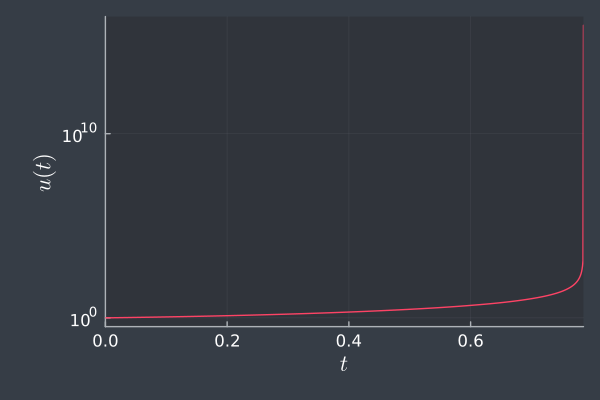

In [24]:
using Plots, LaTeXStrings
theme(:dark);  default(thickness_scaling=1.4)
plot(sol, label=""; xlabel=L"t",  yaxis=(:log10, L"u(t)"))

In [ ]:
using Plots, LaTeXStrings
t = range(0, 3, length=800)
u = @. exp(t) * 1
lower, upper = @. exp(t) * 0.7, @. exp(t) * 1.3
plot(t, u;
    l=:black, ribbon=(lower, upper),
    leg=:none,  xlabel=L"t",  ylabel=L"u(t)",
    title="Exponential divergence of solutions")

But with $u'=-u$, solutions actually get closer together with time.

In [ ]:
u = @. exp(-t) * 1
lower, upper = @. exp(-t) * 0.7, @. exp(-t) * 1.3
plot(t, u;
    l=:black,  ribbon=(lower, upper),
    leg=:none,  xlabel=L"t",  ylabel=L"u(t)",
    title="Exponential convergence of solutions")

In this case the actual condition number is one, because the initial difference between solutions is the largest over all time. Hence the exponentially growing bound $e^{b-a}$ is a gross overestimate.